In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model  import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

In [2]:
df = pd.read_csv("dados_analise_process_seletivo (1).csv")

# converte o period para datetime
df["period"] = pd.to_datetime(df["period"])

# ordena as datas
df = df.sort_values('period').reset_index(drop=True)

# features de tempo
df['month'] = df['period'].dt.month
df['year'] = df['period'].dt.year

# sazonalidade cíclica 
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# tendência linear
df['t'] = np.arange(len(df))

print(df[['period','month_sin','month_cos','t']].head(3))


      period  month_sin     month_cos  t
0 2022-01-31   0.500000  8.660254e-01  0
1 2022-02-28   0.866025  5.000000e-01  1
2 2022-03-31   1.000000  6.123234e-17  2


In [3]:

features = [
    'price',
    'margem',
    'month_sin',
    'month_cos',
    't'
]

X = df[features] #entrada 
y = df["target"] #saída

n_test = 5

X_train = X.iloc[:-n_test]   # linhas 0 a 35
X_test  = X.iloc[-n_test:]   # linhas 36 a 41
y_train = y.iloc[:-n_test]
y_test  = y.iloc[-n_test:]


print(f"Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Treino: 37 amostras | Teste: 5 amostras


In [4]:
# criar scaler
scaler = StandardScaler()


# fit_transform no treino: aprende a média e desvio do treino
X_train_sc = scaler.fit_transform(X_train)

# transform no teste: aplica os parâmetros aprendidos no treino
X_test_sc = scaler.transform(X_test)

# Verificar resultado
print("Média antes:",  X_train['price'].mean().round(1))
print("Média depois:", X_train_sc[:, 0].mean().round(4))  # ≈ 0.0
print("Desvio depois:", X_train_sc[:, 0].std().round(4)) # ≈ 1.0


Média antes: 91.1
Média depois: 0.0
Desvio depois: 1.0


In [5]:
alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 200, 500, 1000] # lista de alphas para teste

# TimeSeriesSplit: mantém a ordem temporal nas folds
tscv = TimeSeriesSplit(n_splits=4)

# GridSearchCV testa cada alpha com cross-validation temporal
grid = GridSearchCV(
    Ridge(),
    param_grid={'alpha': alphas},
    cv=tscv,
    scoring='neg_mean_absolute_error',
    refit=True
)
grid.fit(X_train_sc, y_train)


best_alpha = grid.best_params_['alpha']
print(f"Melhor alpha: {best_alpha}")
print(f"MAE médio CV: {-grid.best_score_:.1f}")


Melhor alpha: 5
MAE médio CV: 628.7


In [6]:
# Treinar com o melhor alpha
model = Ridge(alpha=best_alpha)
model.fit(X_train_sc, y_train)

# Predizer no conjunto de teste
pred = model.predict(X_test_sc)

# Garantir que não haja vendas negativas
pred = np.maximum(pred, 0)

# Calcular métricas
mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

print(f"MAE:  {mae:.1f}")   # erro médio absoluto
print(f"RMSE: {rmse:.1f}")  # raiz do erro quadrático
print(f"R²:   {r2:.3f}")   # proporção da variância explicada

# Ver o peso de cada feature
coefs = pd.Series(model.coef_, index=features)
print("Coeficientes:")
print(coefs.sort_values(ascending=False))

MAE:  940.1
RMSE: 1164.8
R²:   0.121
Coeficientes:
month_sin     196.384118
price          54.794943
t             -71.939053
margem       -234.577778
month_cos   -1000.571367
dtype: float64


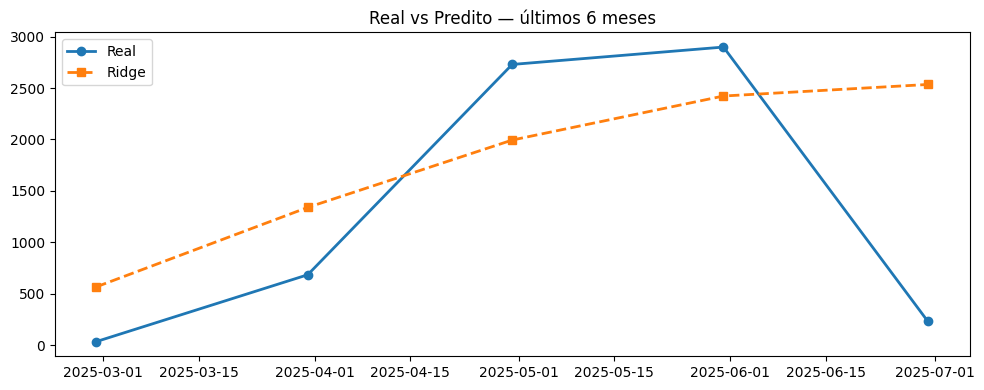

Jul/2024: 2098 unidades previstas
Ago/2024: 1486 unidades previstas
Set/2024: 682 unidades previstas


In [7]:
# Gráfico: real vs predito
datas_teste = df['period'].iloc[-n_test:]

plt.figure(figsize=(10, 4))
plt.plot(datas_teste, y_test.values, 'o-', label='Real', lw=2)
plt.plot(datas_teste, pred, 's--', label='Ridge', lw=2)
plt.title('Real vs Predito — últimos 6 meses')
plt.legend()
plt.tight_layout()
plt.show()

# Predizer meses futuros
ultimo_t = len(df)  # continua a sequência de tendência

futuro = pd.DataFrame({
    'price':     [92.0, 95.0, 88.0],
    'margem':    [0.58, 0.60, 0.62],
    'month_sin': [np.sin(2*np.pi*m/12) for m in [7, 8, 9]],
    'month_cos': [np.cos(2*np.pi*m/12) for m in [7, 8, 9]],
    't':         [ultimo_t, ultimo_t+1, ultimo_t+2]
})

futuro_sc = scaler.transform(futuro)
preds_futuros = np.maximum(model.predict(futuro_sc), 0)

meses = ['Jul/2024', 'Ago/2024', 'Set/2024']
for mes, val in zip(meses, preds_futuros):
    print(f"{mes}: {val:.0f} unidades previstas")